#**Extracción del Archivo Tratado**

Carga el archivo CSV que contiene los datos tratados anteriormente.

📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

Archvo tratado: [Click Here](https://drive.google.com/file/d/1Ws1lhDr_5Lvzt7Lie04FkLnVXkEBiB2p/view?usp=sharing)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv('/content/DF_TRATADO.csv')
data.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#**Eliminación de Columnas Irrelevantes**

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [7]:
data = data.drop(columns=['customerID'])
categorical_cols = data.select_dtypes(include=['object']).columns
categorical_cols

Index(['gender', 'InternetService', 'Contract', 'PaymentMethod'], dtype='object')

In [8]:
data_2 = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [9]:
data_2["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


#**Verificación de la Proporción de Cancelación (Churn)**

In [10]:
Datos_Corr= [
    "Churn",
    "tenure",
    "cuentas_diarias",
    "Charges.Monthly",
    "Charges.Total"
]
df_corr = data_2[Datos_Corr]

In [11]:
corr_matrix = df_corr.corr()
corr_matrix

,Churn,tenure,cuentas_diarias,Charges.Monthly,Charges.Total
Churn,1.000000,-0.354049,0.192858,0.192858,-0.199484
tenure,-0.354049,1.000000,0.246862,0.246862,0.825880
cuentas_diarias,0.192858,0.246862,1.000000,1.000000,0.651065
Charges.Monthly,0.192858,0.246862,1.000000,1.000000,0.651065
Charges.Total,-0.199484,0.825880,0.651065,0.651065,1.000000


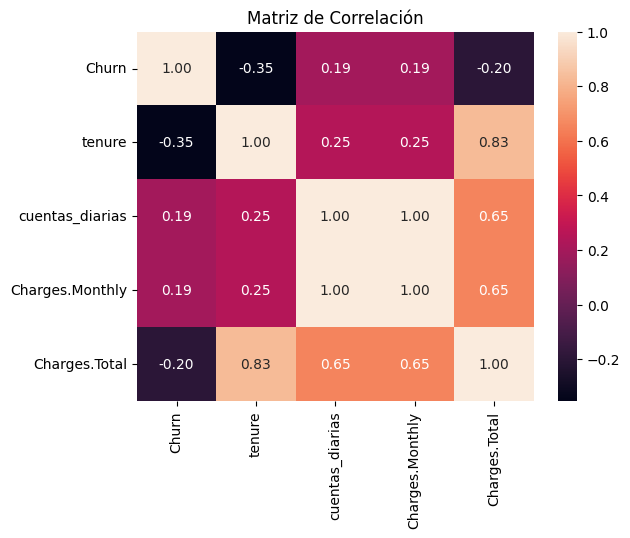

In [12]:
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

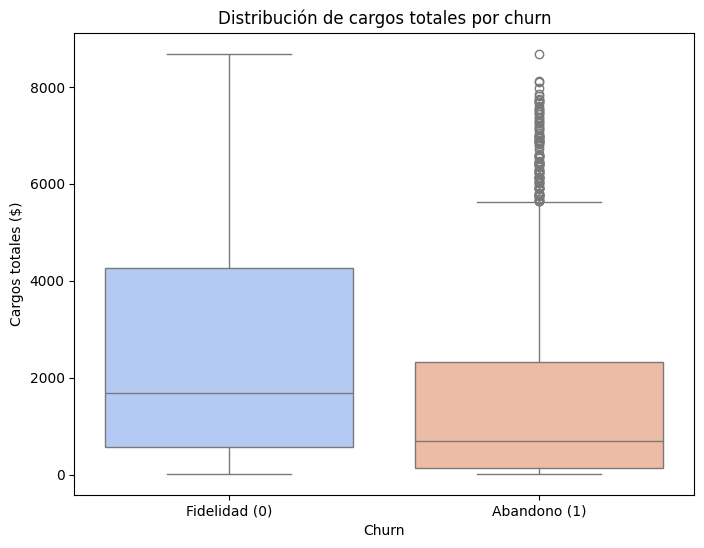

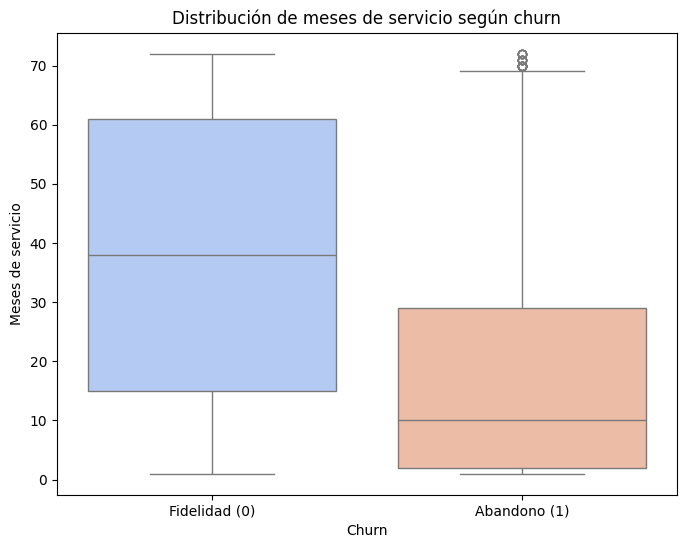

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot de cargos totales según churn
plt.figure(figsize=(8, 6))
sns.boxplot(data=data_2, x='Churn', y='Charges.Total', hue='Churn', palette='coolwarm' , legend=False)
plt.title('Distribución de cargos totales por churn')
plt.xticks([0,1], ['Fidelidad (0)', 'Abandono (1)'])
plt.ylabel('Cargos totales ($)')
plt.show()

# Boxplot de meses de servicio según churn
plt.figure(figsize=(8, 6))
sns.boxplot(data=data_2, x='Churn', y='tenure', hue='Churn', palette = 'coolwarm' , legend=False)
plt.title('Distribución de meses de servicio según churn')
plt.xticks([0,1], ['Fidelidad (0)', 'Abandono (1)'])
plt.ylabel('Meses de servicio')
plt.show()


In [14]:
X = data_2.drop('Churn', axis=1)
y = data_2['Churn']
X

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,Charges.Total,cuentas_diarias,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,9,1,0,0,1,0,1,...,593.30,2.186667,False,False,False,True,False,False,False,True
1,0,0,0,9,1,1,0,0,0,0,...,542.40,1.996667,True,False,False,False,False,False,False,True
2,0,0,0,4,1,0,0,0,1,0,...,280.85,2.463333,True,True,False,False,False,False,True,False
3,1,1,0,13,1,0,0,1,1,0,...,1237.85,3.266667,True,True,False,False,False,False,True,False
4,1,1,0,3,1,0,0,0,0,1,...,267.40,2.796667,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,0,0,13,1,0,1,0,0,1,...,742.90,1.838333,False,False,False,True,False,False,False,True
7028,0,1,0,22,1,1,0,0,0,0,...,1873.70,2.836667,True,True,False,False,False,False,True,False
7029,0,0,0,2,1,0,0,1,0,0,...,92.75,1.676667,True,False,False,False,False,False,False,True
7030,0,1,1,67,1,0,1,0,1,1,...,4627.65,2.261667,True,False,False,False,True,False,False,True


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Separación train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#**MODELOS**

##Regresión Logística

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [17]:
pipe_reg_log= Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

In [18]:
pipe_reg_log.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [20]:
y_pred_log = pipe_reg_log.predict(X_test)

In [21]:
# Métricas básicas
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.8037914691943128
Precision: 0.6443089430894309
Recall: 0.5701438848920863
F1 Score: 0.6049618320610687


Matriz de confusión:
 [[1379  175]
 [ 239  317]]


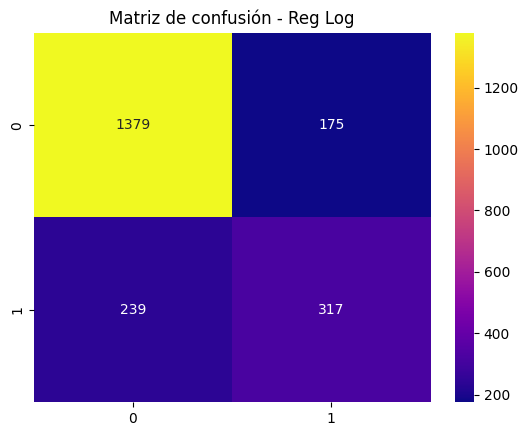

In [22]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log)
print("Matriz de confusión:\n", cm)
sns.heatmap(confusion_matrix(y_test, y_pred_log),
            annot=True,
            fmt="d",
            cmap='plasma')

plt.title("Matriz de confusión - Reg Log")
plt.show()

##Modelo 2

In [23]:
from sklearn.ensemble import RandomForestClassifier
# Creación del modelo
Pipe_RF = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
Pipe_RF.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [24]:
y_pred_RF = Pipe_RF.predict(X_test)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred_RF))
print("Precision:", precision_score(y_test, y_pred_RF))
print("Recall:", recall_score(y_test, y_pred_RF))
print("F1 Score:", f1_score(y_test, y_pred_RF))

Accuracy: 0.7895734597156399
Precision: 0.6233480176211453
Recall: 0.5089928057553957
F1 Score: 0.5603960396039604


Matriz de confusión:
 [[1383  171]
 [ 273  283]]


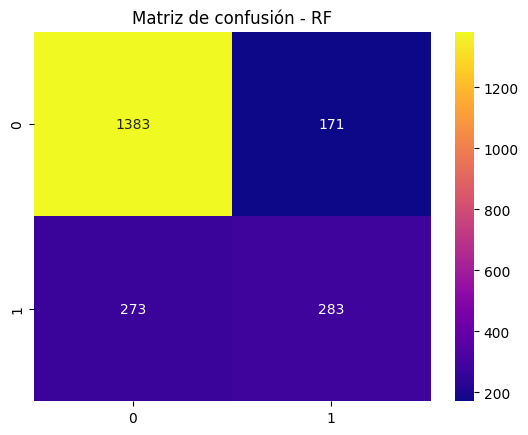

In [26]:
cm = confusion_matrix(y_test, y_pred_RF)
print("Matriz de confusión:\n", cm)
sns.heatmap(confusion_matrix(y_test, y_pred_RF),
            annot=True,
            fmt="d",
            cmap='plasma')

plt.title("Matriz de confusión - RF")
plt.show()

In [27]:
from sklearn.linear_model import LogisticRegression

modelo_final = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

modelo_final.fit(X_train, y_train)

y_pred_final = modelo_final.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("Modelo Final — Regresión Logística Balanceada\n")

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

print("\nReporte completo:\n")
print(classification_report(y_test, y_pred_final))

print("\nMatriz de confusión:\n")
print(confusion_matrix(y_test, y_pred_final))

Modelo Final — Regresión Logística Balanceada

Accuracy: 0.7274881516587678
Precision: 0.4896174863387978
Recall: 0.8057553956834532
F1 Score: 0.6091094493541809

Reporte completo:

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1554
           1       0.49      0.81      0.61       556

    accuracy                           0.73      2110
   macro avg       0.70      0.75      0.70      2110
weighted avg       0.80      0.73      0.74      2110


Matriz de confusión:

[[1087  467]
 [ 108  448]]


In [29]:
import numpy as np

coef = pipe_reg_log.named_steps['model'].coef_[0]          # array de coeficientes
features = X_train.columns                                 # nombres de las variables
importancia = (pd
               .DataFrame({'feature': features,
                            'coeficiente': coef,
                            'abs_coef': np.abs(coef)})
               .sort_values('abs_coef', ascending=False))

print(importancia)

                                  feature  coeficiente  abs_coef
3                                  tenure    -1.619944  1.619944
14                          Charges.Total     0.931989  0.931989
20                      Contract_Two year    -0.662872  0.662872
17            InternetService_Fiber optic     0.633206  0.633206
18                     InternetService_No    -0.544302  0.544302
15                        cuentas_diarias    -0.348091  0.348091
13                        Charges.Monthly    -0.348091  0.348091
19                      Contract_One year    -0.301500  0.301500
10                            StreamingTV     0.201552  0.201552
5                           MultipleLines     0.184762  0.184762
11                        StreamingMovies     0.183874  0.183874
22         PaymentMethod_Electronic check     0.175763  0.175763
12                       PaperlessBilling     0.171310  0.171310
6                          OnlineSecurity    -0.128597  0.128597
9                        

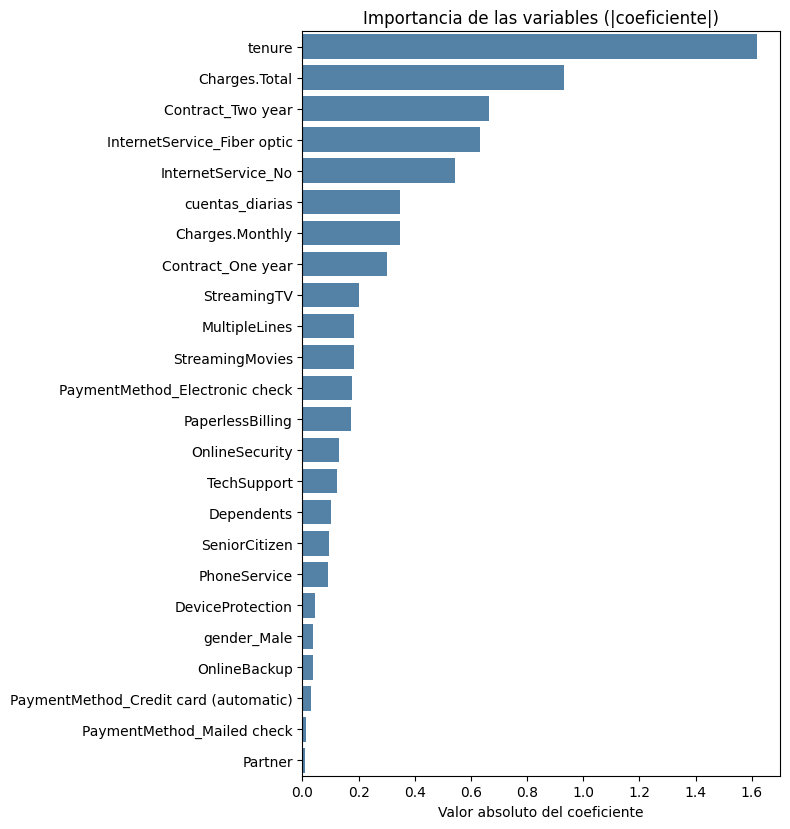

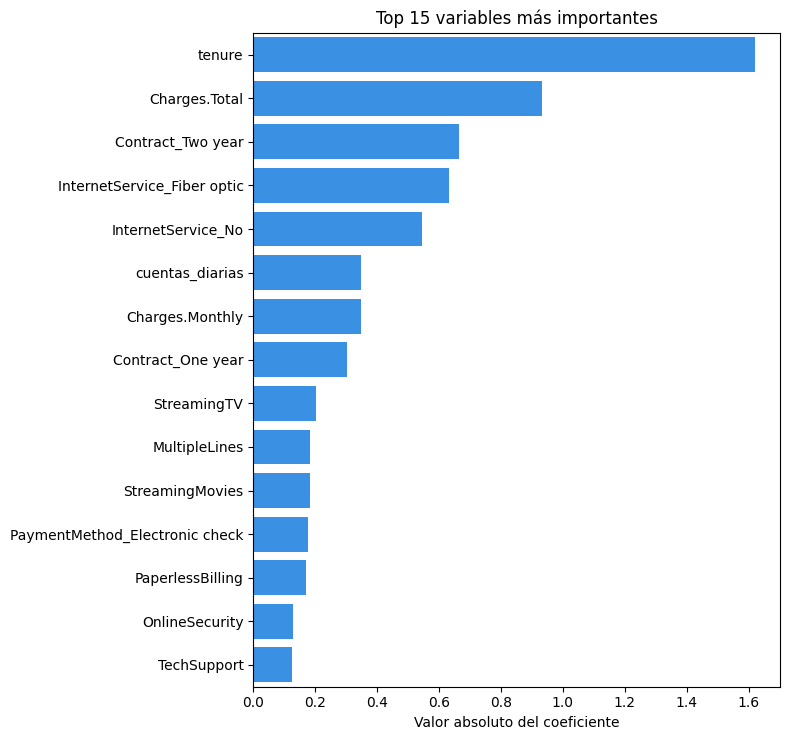

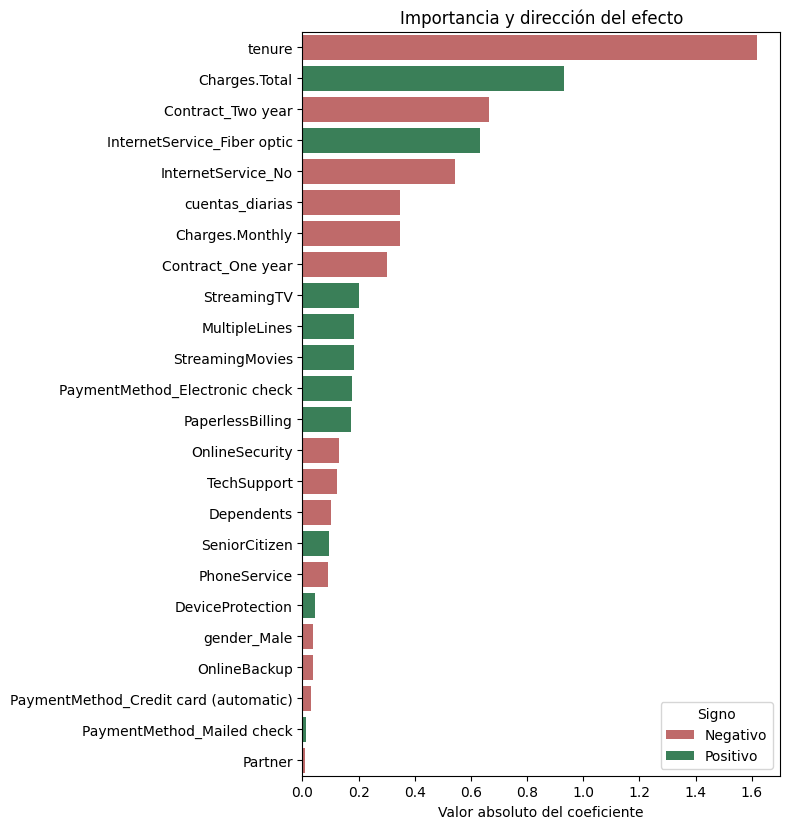

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(8, 0.35*len(importancia)))   # alto dinámico
sns.barplot(x='abs_coef', y='feature',
            data=importancia,
            color='steelblue')
plt.title('Importancia de las variables (|coeficiente|)')
plt.xlabel('Valor absoluto del coeficiente')
plt.ylabel('')
plt.tight_layout()
plt.show()

###############################################################################
N = 15
topN = importancia.head(N)

plt.figure(figsize=(8, 0.5*N))
sns.barplot(x='abs_coef', y='feature',
            data=topN,
            color='dodgerblue')
plt.title(f'Top {N} variables más importantes')
plt.xlabel('Valor absoluto del coeficiente')
plt.ylabel('')
plt.tight_layout()
plt.show()


###############################################################################
importancia['signo'] = np.where(importancia['coeficiente'] >= 0,
                                'Positivo', 'Negativo')

plt.figure(figsize=(8, 0.35*len(importancia)))
sns.barplot(x='abs_coef', y='feature',
            data=importancia,
            hue='signo',
            dodge=False,
            palette={'Positivo': 'seagreen',
                     'Negativo': 'indianred'})
plt.title('Importancia y dirección del efecto')
plt.xlabel('Valor absoluto del coeficiente')
plt.ylabel('')
plt.legend(title='Signo')
plt.tight_layout()
plt.show()

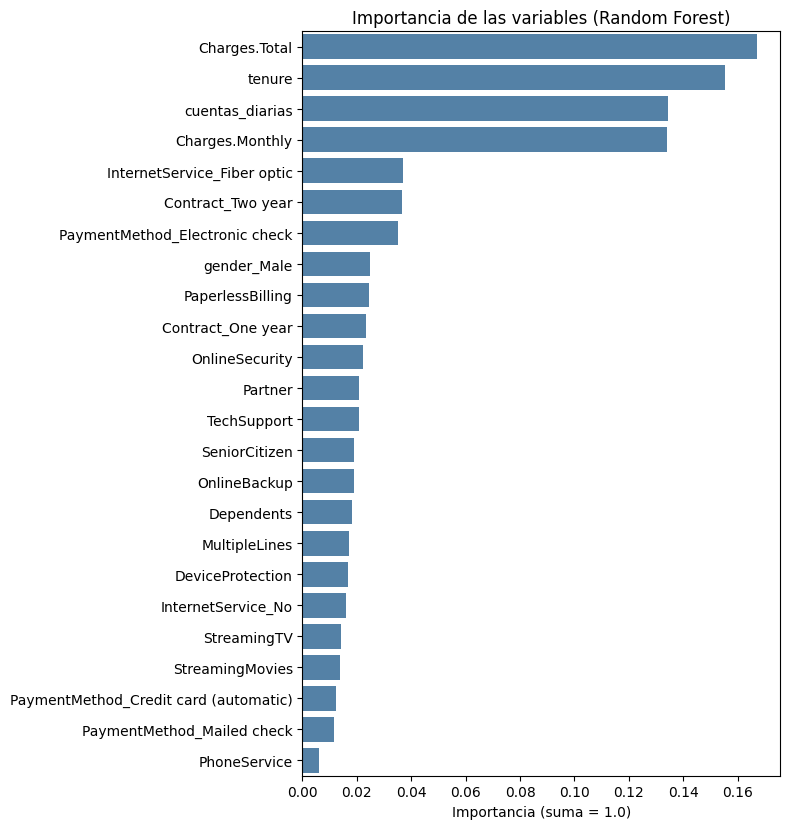

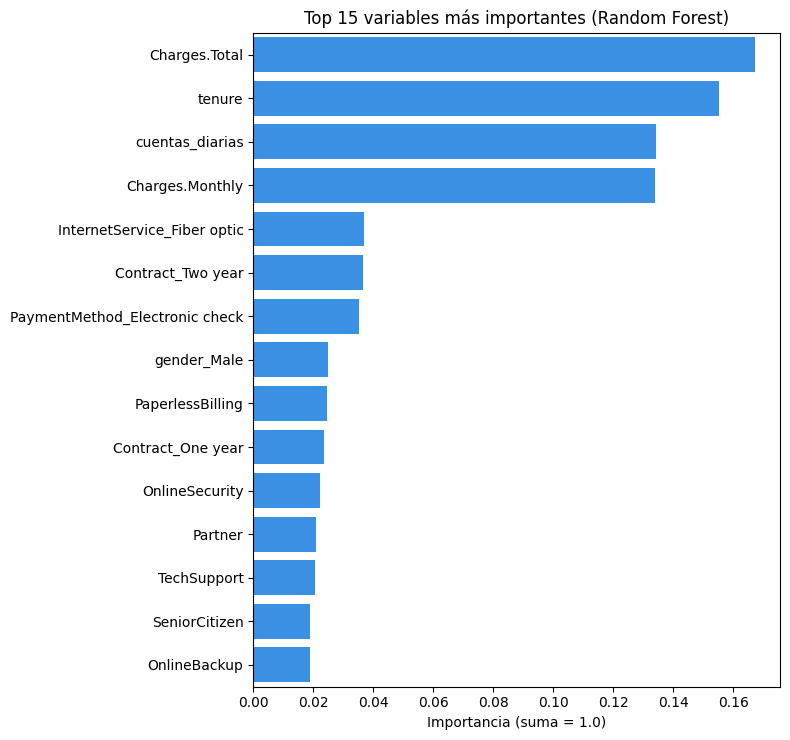

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#
importancia_rf = (pd.DataFrame({'feature': X_train.columns,
                                'importance': Pipe_RF.feature_importances_})
                    .sort_values('importance', ascending=False)
                    .reset_index(drop=True))


plt.figure(figsize=(8, 0.35*len(importancia_rf)))
sns.barplot(x='importance', y='feature',
            data=importancia_rf,
            color='steelblue')
plt.title('Importancia de las variables (Random Forest)')
plt.xlabel('Importancia (suma = 1.0)')
plt.ylabel('')
plt.tight_layout()
plt.show()


N = 15
topN = importancia_rf.head(N)

plt.figure(figsize=(8, 0.5*N))
sns.barplot(x='importance', y='feature',
            data=topN,
            color='dodgerblue')
plt.title(f'Top {N} variables más importantes (Random Forest)')
plt.xlabel('Importancia (suma = 1.0)')
plt.ylabel('')
plt.tight_layout()
plt.show()

#Conclusión

##Hallazgos Principales

El estudio evidencia que la deserción de clientes no ocurre al azar ni se distribuye de forma equitativa, sino que se concentra notablemente en grupos específicos y sigue patrones de conducta claramente identificables.

El factor que más influye es la permanencia del cliente (antigüedad). Los datos demuestran que el peligro de cancelación es significativamente más alto en los primeros meses de relación con la compañía. Esto indica que la deserción es, fundamentalmente, una cuestión de mala adaptación inicial y falta de afianzamiento del cliente. Cuando un usuario logra superar esta etapa temprana y se mantiene por más tiempo, su tendencia a cancelar se reduce drásticamente. Dicho de otro modo, la lealtad se forja con el paso del tiempo.

El segundo aspecto más relevante es la modalidad de contrato. Los acuerdos de larga duración (de 1 o 2 años) actúan como un poderoso instrumento de retención. Esto evidencia no solo un compromiso legal, sino también una mayor solidez en el vínculo comercial. Por el contrario, los usuarios con contratos mensuales gozan de una libertad que aumenta su predisposición a darse de baja ante cualquier descontento, una oferta mejor de la competencia o la sensación de que el servicio es demasiado caro.

El tercer elemento crucial se vincula con el volumen de gasto y la categoría de servicio contratado. Los usuarios con facturaciones más elevadas y aquellos que disponen de fibra óptica presentan un riesgo mayor de deserción. Esto podría explicarse como una cuestión de expectativas: los clientes de tipo premium suelen abonar más y, en consecuencia, demandan una calidad, estabilidad y atención superiores. Si la experiencia no está a la altura de lo que esperan, el peligro de baja se incrementa. No obstante, también se aprecia que servicios adicionales como la asistencia técnica o la seguridad en línea disminuyen la deserción, lo que apunta a que ofrecer un valor agregado y un respaldo continuo consolida la fidelidad del cliente.

En resumen, el análisis revela que la deserción responde a tres aspectos fundamentales:

La etapa del ciclo de vida en que se encuentra el cliente (particularmente la fase inicial).

El grado de vinculación contractual.

La calidad de la experiencia ofrecida a los segmentos de mayor valor.

Desde un punto de vista estratégico, esto significa que combatir la deserción requiere un enfoque preventivo y personalizado. No basta con reaccionar cuando el cliente ya ha manifestado su intención de irse; es necesario anticiparse al peligro desde el proceso de incorporación, incentivar la contratación de plazos más largos y garantizar una experiencia excelente a los usuarios más valiosos.

##Modelos Utilizados

Al contrastar el desempeño del modelo de Bosque Aleatorio (Random Forest) con el de Regresión Logística, se determina que este último ofrece resultados consistentemente mejores en las métricas de evaluación fundamentales.

Aunque ambos modelos arrojan cifras relativamente parecidas, la Regresión Logística consigue una mayor exactitud (accuracy), lo que apunta a un acierto global superior al clasificar a los usuarios. Pero lo que resulta aún más relevante es que presenta un mayor recall (sensibilidad) para la clase positiva (clientes que se dan de baja), lo que implica que es más eficaz detectando a quienes realmente terminan cancelando el servicio. Este aspecto cobra especial importancia en situaciones de deserción, ya que no identificar a tiempo a un cliente que se va (falso negativo) puede traducirse en pérdidas económicas y de oportunidad para el negocio.

Asimismo, la Regresión Logística muestra una precisión ligeramente más alta, lo que significa que, cuando pronostica la baja de un cliente, hay más probabilidades de que su predicción sea acertada. También minimiza la cantidad de falsos negativos en comparación con el Bosque Aleatorio, potenciando así la habilidad del modelo para prever el abandono.

Como conclusión, si bien el Bosque Aleatorio es una técnica sólida y de gran potencial, en este contexto particular la Regresión Logística proporciona una combinación más ventajosa de rendimiento, capacidad de predicción y sencillez interpretativa. Por este motivo, se considera la opción más idónea para resolver el desafío de pronosticar la deserción de clientes en el presente estudio.